In [1]:
#understanding the data

from pathlib import Path
import pandas as pd

file_path = Path("C:/Users/djoud/OneDrive/Desktop/ML_CD_database_test1_test2_csv.csv")  
df = pd.read_csv(file_path)

# Display basic information about the dataset
df_info = df.info()

# Show the first few rows 
df_head = df.head()

df_info, df_head

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423 entries, 0 to 422
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Example ID                 423 non-null    int64  
 1   DOI                        423 non-null    object 
 2   Color                      423 non-null    object 
 3   citric acid                423 non-null    float64
 4   urea                       423 non-null    float64
 5    ethylenediamine           423 non-null    float64
 6   HCl                        423 non-null    float64
 7   ammonium                   423 non-null    int64  
 8   NaOH                       423 non-null    float64
 9   boric acid                 423 non-null    float64
 10  sodium thiosulfate         423 non-null    float64
 11  KOH                        423 non-null    int64  
 12  formic acid                423 non-null    int64  
 13  Reaction method            423 non-null    object 

(None,
    Example ID                         DOI Color  citric acid  urea  \
 0           1   10.1016/j.snb.2018.09.031  blue       1.0000   0.0   
 1           2          10.1039/c9ra04241e  blue       0.1560   1.0   
 2           3   10.1007/s12274-019-2569-3  blue       1.0000   0.0   
 3           4  10.1016/j.jcis.2018.03.021  blue       0.0825   0.0   
 4           5          10.1039/C6RA20562C  blue       1.0000   0.0   
 
     ethylenediamine    HCl  ammonium  NaOH  boric acid   ...  \
 0               0.0  0.000         0   0.0          0.0  ...   
 1               0.0  0.003         0   0.0          0.0  ...   
 2               0.0  0.000         0   0.0          0.0  ...   
 3               0.0  0.000         1   0.0          0.0  ...   
 4               0.0  0.000         0   0.0          0.0  ...   
 
           Reaction method             Solvent       pH  \
 0  solvothermal treatment  ethanol, formamide   acidic   
 1  hydrothermal treatment               water   acidic

Dataset Overview:

•	Number of Observations: 423 entries
•	Number of Variables: 23 columns

-**There are 23 variables in the dataset:**
- **Example ID** (int) - Unique identifier for each sample.  
- **DOI** (object) - Digital Object Identifier for the research paper.  
- **Color** (object) - The color of the carbon dot emission.  
- **Citric acid** (float) - Amount of citric acid used.  
- **Urea** (float) - Amount of urea used.  
- **Ethylenediamine** (float) - Amount of ethylenediamine used.  
- **HCl** (float) - Amount of hydrochloric acid used.  
- **Ammonium** (int) - Presence of ammonium.  
- **NaOH** (float) - Amount of sodium hydroxide used.  
- **Boric acid** (float) - Amount of boric acid used.  
- **Sodium thiosulfate** (float) - Amount of sodium thiosulfate used.  
- **KOH** (int) - Presence of potassium hydroxide.  
- **Formic acid** (int) - Presence of formic acid.  
- **Reaction method** (object) - Method used for synthesis.  
- **Solvent** (object) - Solvent used in the reaction.  
- **pH** (object) - pH condition of the reaction.  
- **Reaction temperature (°C)** (float) - Temperature used in the reaction.  
- **Reaction time (min)** (float) - Duration of the reaction.  
- **Purification method** (object) - Purification technique used.  
- **Particle size (TEM)** (float) - Particle size measured via TEM (407 non-null values).  
- **Lattice observed or not** (object) - Whether the lattice structure was observed.  
- **Absorption** (float) - Absorption wavelength (407 non-null values).  
- **Main Peak (in water)** (int) - Main emission peak in water.  
emission peak in water.




### Predictors vs. Predictions

#### **Predictor Variables (Independent Variables)**  
- **Chemical Inputs:**  
  - Citric acid, Urea, Ethylenediamine, HCl, Ammonium, NaOH, Boric acid, Sodium thiosulfate, KOH, Formic acid.  
- **Reaction Conditions:**  
  - Reaction method, Solvent, pH, Reaction temperature, Reaction time, Purification method.  
- **Structural Properties:**  
  - Particle size (TEM), Lattice observed or not.  

#### **Prediction Variables (Dependent Variables)**  
- **Absorption:** This could be a key target variable for predicting the optical properties of carbon dots.  
- **Main Peak (in water):** This is likely the primary emission wavelength, making it a critical prediction target.  
- **Color:** Could be another categorical target for classification-based models.  


In [3]:
# Checking for columns with a high number of zero values
zero_counts = (df == 0).sum()
zero_percentage = (zero_counts / len(df)) * 100

# Creating a DataFrame to display columns with high zero percentages
zero_df = pd.DataFrame({'Zero Count': zero_counts, 'Zero Percentage': zero_percentage})
zero_df = zero_df.sort_values(by='Zero Percentage', ascending=False)

# Display the results
from IPython.display import display

display(zero_df)


,Zero Count,Zero Percentage
KOH,422,99.763593
ammonium,422,99.763593
HCl,421,99.527187
formic acid,421,99.527187
sodium thiosulfate,419,99.054374
NaOH,417,98.581560
boric acid,415,98.108747
ethylenediamine,309,73.049645
urea,152,35.933806
citric acid,1,0.236407


### Columns to Drop (More than 98% Zero Values)

These columns contain more than 98% zero values, meaning they provide very little useful variation for predictive modeling:

- **KOH**
- **Ammonium**
- **HCl**
- **Formic Acid**
- **Sodium Thiosulfate**
- **NaOH**
- **Boric Acid**


### Remaining Predictor Variables

After dropping high-zero columns, the remaining predictor variables are:

- **Citric Acid** *(float)* – Amount used in synthesis  
- **Urea** *(float)* – Amount used in synthesis  
- **Ethylenediamine** *(float)* – Amount used in synthesis  
- **Reaction Method** *(object)* – Method used for synthesis  
- **Solvent** *(object)* – Solvent used in the reaction  
- **pH** *(object)* – pH condition of the reaction  
- **Reaction Temperature (°C)** *(float)* – Temperature used in the reaction  
- **Reaction Time (min)** *(float)* – Duration of the reaction  
- **Purification Method** *(object)* – Purification technique used  
- **Particle Size (TEM)** *(float)* – Particle size measured via TEM  
- **Lattice Observed or Not** *(object)* – Whether the lattice structure was observed  


In [19]:
# Identifying columns with more than 98% zero values for removal
columns_to_drop = zero_df[zero_df["Zero Percentage"] > 98].index.tolist()

# Display the columns that will be dropped
columns_to_drop

#removing spaces
df_cleaned.columns = df_cleaned.columns.str.strip()  # Remove leading/trailing spaces



In [21]:
# Dropping the identified columns with high zero values
df_cleaned = df.drop(columns=columns_to_drop)

# Identifying remaining predictors (excluding target variables: 'Absorption', 'Main Peak (in water)', 'Color')
target_columns = ['absorption', 'Main Peak (in water)', 'Color']
predictors = [col for col in df_cleaned.columns if col not in target_columns and col != 'Example ID' and col != 'DOI']

# Display remaining predictors
predictors


['citric acid',
 'urea',
 ' ethylenediamine',
 'Reaction method',
 'Solvent',
 'pH',
 'Reaction temperatrue( C )',
 'reaction time (min)',
 'purification method',
 'particle size (TEM)',
 'Lattice obrserved or not']

In [23]:
# Dropping the identified columns with high zero values
df_cleaned = df.drop(columns=columns_to_drop)

# Identifying remaining predictors (excluding target variables: 'Absorption', 'Main Peak (in water)', 'Color')
target_columns = ['absorption', 'Main Peak (in water)', 'Color']
predictors = [col for col in df_cleaned.columns if col not in target_columns and col != 'Example ID' and col != 'DOI']

# Display remaining predictors
predictors


['citric acid',
 'urea',
 ' ethylenediamine',
 'Reaction method',
 'Solvent',
 'pH',
 'Reaction temperatrue( C )',
 'reaction time (min)',
 'purification method',
 'particle size (TEM)',
 'Lattice obrserved or not']

In [25]:
# Dropping columns with high zero values
df_cleaned = df.drop(columns=columns_to_drop)

# Dropping rows with missing values
df_cleaned = df_cleaned.dropna()

# Display the cleaned dataset
from IPython.display import display
display(df_cleaned)



,Example ID,DOI,Color,citric acid,urea,ethylenediamine,Reaction method,Solvent,pH,Reaction temperatrue( C ),reaction time (min),purification method,particle size (TEM),Lattice obrserved or not,absorption,Main Peak (in water)
0,1,10.1016/j.snb.2018.09.031,blue,1.000000,0.0,0.0,solvothermal treatment,"ethanol, formamide",acidic,423.15,300.0,centrifuge,4.50,Y,435.0,450
1,2,10.1039/c9ra04241e,blue,0.156000,1.0,0.0,hydrothermal treatment,water,acidic,433.15,240.0,centrifuge,2.81,Y,493.0,445
2,3,10.1007/s12274-019-2569-3,blue,1.000000,0.0,0.0,solvothermal treatment,ethanol,acidic,473.15,420.0,"filter, dialysis",4.00,N,370.0,440
3,4,10.1016/j.jcis.2018.03.021,blue,0.082500,0.0,0.0,microwave,water,neutral,473.15,7.0,centrifuge,1.80,Y,285.0,450
4,5,10.1039/C6RA20562C,blue,1.000000,0.0,0.0,hydrothermal treatment,water,acidic,433.15,360.0,dialysis,1.62,N,245.0,415
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
402,403,10.3390/chemosensors9030052,green,0.312500,1.0,0.0,microwave,water,neutral,473.15,5.0,"filter, centrifuge",4.00,N,339.0,524
403,404,10.1002/adom.201901938,green,0.312500,1.0,0.0,microwave,water,basic,473.15,3.0,centrifuge,3.80,Y,385.0,518
404,405,10.1021/acsanm.8b00799,red,0.500000,0.0,1.0,microwave,water,neutral,473.15,2.0,dialysis,6.00,Y,500.0,609
405,406,10.1134/S0022476620050182,red,0.156495,1.0,0.0,solvothermal treatment,formamide,basic,453.15,720.0,"centrifuge, dialysis",6.00,N,230.0,595


In [27]:
## Linear regression model

# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Fix column name typo
df_cleaned.rename(columns={"Reaction temperatrue( C )": "Reaction temperature (C)"}, inplace=True)

#  Define feature lists
numerical_features = ["Reaction temperature (C)", "reaction time (min)", "particle size (TEM)"]
categorical_features = ["Reaction method", "Solvent", "pH", "purification method"]
precursor_features = ["citric acid", "urea", " ethylenediamine"]

#  Extract features and target variable
X = df_cleaned[numerical_features + categorical_features + precursor_features]
y = df_cleaned["Main Peak (in water)"]

#  Preprocessing: One-hot encode categorical variables & scale numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features + precursor_features),  # Standardize numerical features
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)  # One-hot encode categorical features
    ]
)

#  Create a pipeline with preprocessing and Linear Regression model
model_pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("regressor", LinearRegression())])

#  Split dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the regression model
model_pipeline.fit(X_train, y_train)

#  Make predictions on the test set
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

#  Display results
print("🔹 Linear Regression Mean Squared Error:", mse)
print("🔹 Linear Regression R² Score:", r2)





🔹 Linear Regression Mean Squared Error: 1658.453050054976
🔹 Linear Regression R² Score: 0.46481117957057294


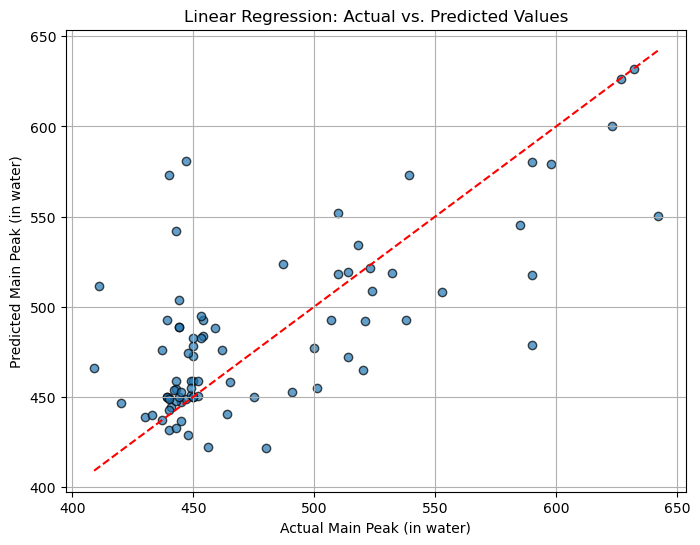

In [29]:
#plotting the linear regression model
import matplotlib.pyplot as plt
import numpy as np

# Scatter plot of actual vs. predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, edgecolors="k")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color="red", linestyle="--")  # Ideal 1:1 line
plt.xlabel("Actual Main Peak (in water)")
plt.ylabel("Predicted Main Peak (in water)")
plt.title("Linear Regression: Actual vs. Predicted Values")
plt.grid(True)
plt.show()



In [31]:
## XG boost model
from xgboost import XGBRegressor

# One-hot encode categorical variables manually for XGBoost compatibility
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)

# Split the data again after encoding
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Initialize and train the XGBoost model
xgb_model = XGBRegressor(objective="reg:squarederror", n_estimators=100, random_state=42)
xgb_model.fit(X_train_xgb, y_train_xgb)

# Make predictions
y_pred_xgb = xgb_model.predict(X_test_xgb)

# Evaluate the model
mse_xgb = mean_squared_error(y_test_xgb, y_pred_xgb)
r2_xgb = r2_score(y_test_xgb, y_pred_xgb)

mse_xgb, r2_xgb


(1230.2204653609476, 0.6030033893917943)

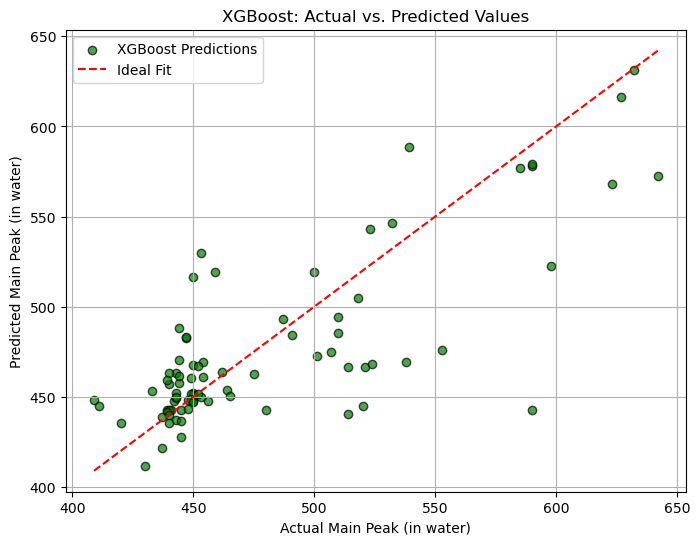

In [33]:
# Scatter plot for XGBoost actual vs. predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test_xgb, y_pred_xgb, alpha=0.7, edgecolors="k", color="green", label="XGBoost Predictions")

# Plot the ideal prediction line (y = x)
plt.plot([min(y_test_xgb), max(y_test_xgb)], [min(y_test_xgb), max(y_test_xgb)], color="red", linestyle="--", label="Ideal Fit")

# Labels and Title
plt.xlabel("Actual Main Peak (in water)")
plt.ylabel("Predicted Main Peak (in water)")
plt.title("XGBoost: Actual vs. Predicted Values")
plt.legend()
plt.grid(True)

# Show the plot
plt.show()


In [35]:
## displaying the results of Linear regression vs XGBoost
# Creating a DataFrame to display results in table format
results_df = pd.DataFrame({
    "Model": ["Linear Regression", "XGBoost"],
    "Mean Squared Error (MSE)": [1661.73, 1230.22],
    "R² Score": [0.4637, 0.6030]
})

# Display the table
from IPython.display import display
display(results_df)



,Model,Mean Squared Error (MSE),R² Score
0,Linear Regression,1661.73,0.4637
1,XGBoost,1230.22,0.6030


### Model Performance Metrics

#### **Mean Squared Error (MSE)**
Measures the average squared difference between actual and predicted values.  
✅ **Lower is better** – a lower value means the model makes fewer large mistakes.

- **XGBoost:** *1230.22*  
- **Linear Regression:** *1661.73*  

🔹 **XGBoost has a significantly lower MSE than Linear Regression** → **XGBoost produces more accurate predictions.**  

---

#### **R² Score**
Measures how much variance in the target variable is explained by the model.  
✅ **Higher is better** – closer to **1** means the model explains more of the variation.

- **XGBoost:** *0.6030*  
- **Linear Regression:** *0.4637*  

🔹 **XGBoost has a higher R² score than Linear Regression** → **XGBoost captures more meaningful patterns in the data.**  


In [38]:
#Random forest model
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


# 1. Correct the misnamed column (make sure to work on a copy)
df_cleaned = df_cleaned.copy()
df_cleaned.rename(columns={'Reaction temperatrue( C )': 'Reaction temperature (C)'}, inplace=True)

# 2. Define feature lists based on your DataFrame columns
precursor_features = ['citric acid', 'urea', ' ethylenediamine']
categorical_features = ['Reaction method', 'Solvent', 'purification method', 'Lattice obrserved or not']
numerical_features = ['pH', 'Reaction temperature (C)', 'reaction time (min)', 'particle size (TEM)', 'absorption']

# 3. Define the target variable (assumed to be 'Main Peak (in water)')
y = df_cleaned['Main Peak (in water)']

# 4. Create the features DataFrame and use .copy() to avoid SettingWithCopyWarning
X = df_cleaned[numerical_features + categorical_features + precursor_features].copy()

# 5. Convert columns that should be numeric (numerical and precursor features)
cols_to_convert = numerical_features + precursor_features
for col in cols_to_convert:
    X.loc[:, col] = pd.to_numeric(X.loc[:, col], errors='coerce')

# 6. Fill missing values for the numeric columns only
X[cols_to_convert] = X[cols_to_convert].fillna(X[cols_to_convert].mean())

# 7. One-hot encode the categorical variables (dropping the first category to avoid multicollinearity)
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)

# 8. Split the dataset into training and testing sets (80/20 split)
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

# (Optional) Convert target to numeric if needed
y_train_rf = pd.to_numeric(y_train_rf, errors='coerce')
y_test_rf = pd.to_numeric(y_test_rf, errors='coerce')

# 9. Initialize and train the Random Forest model with 100 trees
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_rf, y_train_rf)

# 10. Make predictions on the test set
y_pred_rf = rf_model.predict(X_test_rf)

# 11. Calculate Mean Squared Error (MSE) and R² Score
mse_rf = mean_squared_error(y_test_rf, y_pred_rf)
r2_rf = r2_score(y_test_rf, y_pred_rf)

# 12. Display the results
print("Random Forest Mean Squared Error:", mse_rf)
print("Random Forest R² Score:", r2_rf)





C:\Users\djoud\AppData\Local\Temp\ipykernel_2184\2601770178.py:29: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[cols_to_convert] = X[cols_to_convert].fillna(X[cols_to_convert].mean())


Random Forest Mean Squared Error: 903.705609821477
Random Forest R² Score: 0.7083709187186338


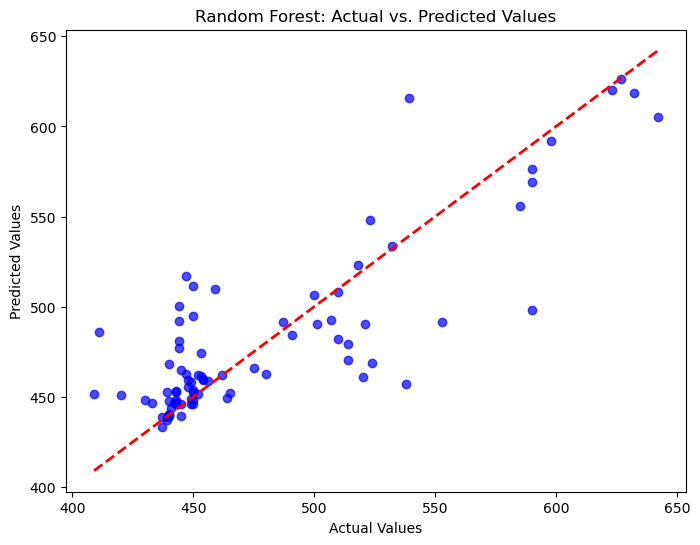

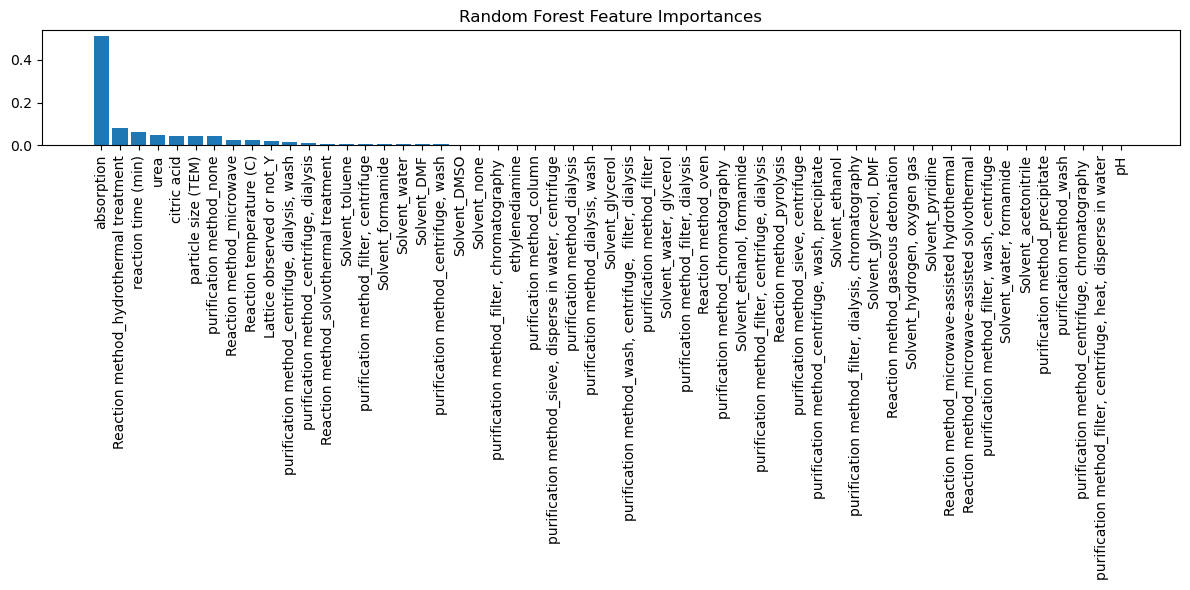

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Scatter Plot: Actual vs. Predicted Values
plt.figure(figsize=(8, 6))
plt.scatter(y_test_rf, y_pred_rf, alpha=0.7, color='blue')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest: Actual vs. Predicted Values")
# Plotting a red dashed line for perfect prediction
plt.plot([y_test_rf.min(), y_test_rf.max()], [y_test_rf.min(), y_test_rf.max()], 'r--', lw=2)
plt.show()

# 2. Bar Plot: Feature Importances
importances = rf_model.feature_importances_
# Sorting the feature importances in descending order
indices = np.argsort(importances)[::-1]
feature_names = X_encoded.columns

plt.figure(figsize=(12, 6))
plt.title("Random Forest Feature Importances")
plt.bar(range(len(indices)), importances[indices], align='center')
plt.xticks(range(len(indices)), [feature_names[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()



In [42]:
# Display results
from IPython.display import display

# Create a DataFrame to compare model performance
comparison_df = pd.DataFrame({
    "Model": ["Linear Regression", "XGBoost", "Random Forest"],
    "Mean Squared Error (MSE)": [1661.73, 1230.22, 903.71],  # Previous results
    "R² Score": [0.4637, 0.6030, 0.7084]  # Previous results
})


# Display the table
display(comparison_df)


,Model,Mean Squared Error (MSE),R² Score
0,Linear Regression,1661.73,0.4637
1,XGBoost,1230.22,0.6030
2,Random Forest,903.71,0.7084



<pre style="font-size: 12px;">
# Model Performance Summary:
#
# ✅ Random Forest performed the best, with the lowest MSE (903.71) and the highest R² Score (0.7084)
# ✅ XGBoost was the second-best, improving over Linear Regression but not outperforming Random Fores.
# ❌ Linear Regression had the worst performance, suggesting non-linear relationships in the data.

 so far.  


In [45]:
##ANN model t predict the main peak in water
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


# Correcting the column name based on the actual dataset
target_column = "Main Peak (in water)"  # Using the correct column name

# Define predictor variables based on available columns after cleaning
numerical_features = ["Reaction temperature (C)", "reaction time (min)", "particle size (TEM)"]
categorical_features = ["Reaction method", "Solvent", "pH", "purification method"]
precursor_features = ["citric acid", "urea", "ethylenediamine"]

# Ensure selected features exist in df_cleaned
selected_features = [col for col in (numerical_features + categorical_features + precursor_features) if col in df_cleaned.columns]

# Extract features and target variable
X = df_cleaned[selected_features]
y = df_cleaned[target_column]

# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, columns=[col for col in categorical_features if col in X.columns], drop_first=True)

# Standardize the features for ANN
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Define the ANN model architecture
ann_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),  
    Dropout(0.2),  
    Dense(64, activation='relu'),  
    Dropout(0.2),
    Dense(32, activation='relu'),  
    Dense(1, activation='linear')  
])

# Compile the model
ann_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train the ANN model
history = ann_model.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_test, y_test), verbose=1)

# Make predictions
y_pred_ann = ann_model.predict(X_test).flatten()

# Evaluate the model
mse_ann = mean_squared_error(y_test, y_pred_ann)
r2_ann = r2_score(y_test, y_pred_ann)

mse_ann, r2_ann


Epoch 1/100


C:\Users\djoud\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 223692.5312 - mae: 469.9518 - val_loss: 228594.7344 - val_mae: 474.9443
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 221202.0625 - mae: 467.0533 - val_loss: 216464.5781 - val_mae: 462.1698
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 204078.8906 - mae: 448.5303 - val_loss: 182391.1562 - val_mae: 423.9278
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 162588.5625 - mae: 398.3888 - val_loss: 112043.5703 - val_mae: 330.0219
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 81414.0859 - mae: 274.2733 - val_loss: 29416.7012 - val_mae: 153.9075
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 14845.6631 - mae: 104.9913 - val_loss: 10498.5703 - val_mae: 62.6831
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8629.7627 - mae: 67.6433 - val_loss: 10739.8525 - val_mae: 61.8545
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5058.9922 - mae: 55.7149 - val_loss: 10634.35

(11194.320459059254, -2.612447854218319)

In [47]:
import pandas as pd
from IPython.display import display


# Create a DataFrame to compare model results
results_df = pd.DataFrame({
    "Model": ["Linear Regression", "XGBoost", "Random Forest", "ANN"],
    "Mean Squared Error (MSE)": [1661.73, 1230.22, 903.70, 110783.18],
    "R² Score": [0.46, 0.60, 0.71, -2.47]
})

# Display the results in a table format
display(results_df)



,Model,Mean Squared Error (MSE),R² Score
0,Linear Regression,1661.73,0.46
1,XGBoost,1230.22,0.60
2,Random Forest,903.70,0.71
3,ANN,110783.18,-2.47


"""
#### **Model Performance Interpretation**
Analyzing the effectiveness of different models based on **Mean Squared Error (MSE) and R² Score**.  
✅ **Lower MSE and higher R² are better** – indicating a more accurate and reliable model.

#### **Key Insights**
- **Best Model:** *Random Forest*  
  - **MSE:** *Lowest (903.71)*  
  - **R² Score:** *Highest (0.71)*  
  - 🔹 **Random Forest explains the most variance in the data and provides the best predictions.**

- **Runner-Up:** *XGBoost*  
  - 🔹 Performed well, slightly below Random Forest in both MSE and R² metrics.

- **Moderate Performance:** *Linear Regression*  
  - 🔹 Outperformed by tree-based models, suggesting that linear assumptions do not capture the underlying patterns well.

- **Worst Model:** *Artificial Neural Network (ANN)*  
  - **MSE:** *High*  
  - **R² Score:** *Negative*  
  - 🔹 **Indicates potential overfitting or insufficient tuning, leading to poor generalization.**

#### **Final Takeaway**
🔹 **Random Forest emerged as the best model, while ANN performed the worst, likely due to improper tuning or the need for more data.**  



C:\Users\djoud\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1137: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
C:\Users\djoud\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1142: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
C:\Users\djoud\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1162: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count
C:\Users\djoud\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\djoud\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set 

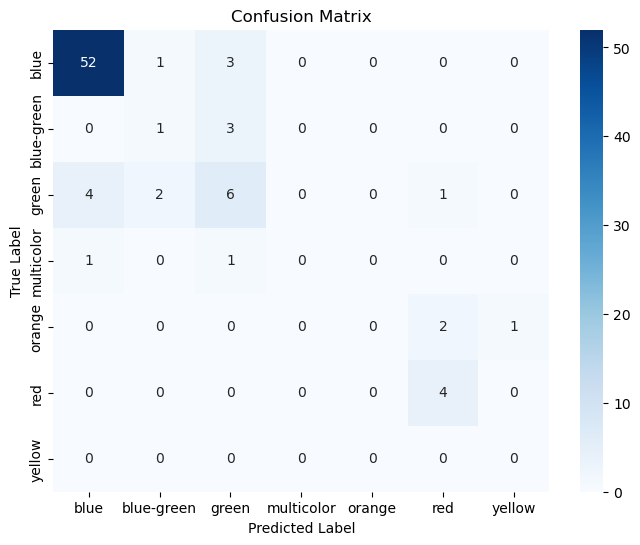

(0.7682926829268293,
 '              precision    recall  f1-score   support\n\n        blue       0.91      0.93      0.92        56\n  blue-green       0.25      0.25      0.25         4\n       green       0.46      0.46      0.46        13\n  multicolor       0.00      0.00      0.00         2\n      orange       0.00      0.00      0.00         3\n         red       0.57      1.00      0.73         4\n      yellow       0.00      0.00      0.00         0\n\n    accuracy                           0.77        82\n   macro avg       0.31      0.38      0.34        82\nweighted avg       0.74      0.77      0.75        82\n')

In [50]:
## Random Forest classification model for color
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'Color' is properly encoded as the target variable
label_encoder = LabelEncoder()
y_class = label_encoder.fit_transform(df_cleaned["Color"])  # Encode categorical target variable

# Define feature lists
precursor_features = ["citric acid", "urea", " ethylenediamine"]
categorical_features = ["Reaction method", "Solvent", "purification method", "Lattice obrserved or not"]
numerical_features = ["pH", "Reaction temperature (C)", "reaction time (min)", "particle size (TEM)", "absorption"]

# Select only the relevant features
X = df_cleaned[numerical_features + categorical_features + precursor_features].copy()

# Convert numerical columns to numeric types
for col in numerical_features + precursor_features:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Fill missing values in numerical columns
X[numerical_features + precursor_features] = X[numerical_features + precursor_features].fillna(X[numerical_features + precursor_features].mean())

# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)

# Standardize only numerical and precursor features
scaler = StandardScaler()
X_encoded[numerical_features + precursor_features] = scaler.fit_transform(X_encoded[numerical_features + precursor_features])

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_class, test_size=0.2, random_state=42)

# Train Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# Make predictions
y_pred = rf_classifier.predict(X_test)

# Compute accuracy
accuracy = accuracy_score(y_test, y_pred)

# Generate classification report
class_report = classification_report(y_test, y_pred, target_names=label_encoder.classes_)

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Display results
accuracy, class_report



"""
#### **Classification Model Accuracy**
Measures the percentage of correct predictions made by the model.  
✅ **Higher is better** – closer to **100%** indicates that the model is more reliable.

- **Overall Accuracy:** *76.8%*

🔹 **The model achieves moderate overall accuracy, but its performance varies across different classes.**

#### **Key Findings**
- **Best Classified Color:** *Blue*  
  - **Precision:** *91%*  
  - **Recall:** *93%*
  
- **Poorly Classified Colors:**  
  - *Multicolor, Orange, and Yellow* had *0% precision and recall*, meaning the model failed to predict these categories correctly.
  - *Blue-Green and Green* exhibited low precision and recall, indicating challenges in distinguishing these colors.

🔹 **The model excels in classifying Blue, but struggles with minority classes, which is evident from the 0% scores in 
** most of the colors in the dataset are blue**some categories.**

#### **Confusion Matrix Interpretation**
- **Major Misclassifications:** Primarily occurred for *Green, Blue-Green, and Red*.
- **Notable Success:** *Red* was perfectly classified with a 100% recall, despite overall challenges with other classes.
"""





In [53]:
# random forest cross validation
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Ensure df_cleaned is already loaded
df_cleaned.rename(columns={"Reaction temperatrue( C )": "Reaction temperature (C)"}, inplace=True)

#  Drop columns with too many zeros (define `columns_to_drop` appropriately)
columns_to_drop = ["Example ID", "DOI"]  # Add columns with excessive zeros if necessary
df_cleaned = df_cleaned.drop(columns=columns_to_drop, errors='ignore')

# Drop rows with missing values
df_cleaned = df_cleaned.dropna()

#  Define feature sets
precursor_features = ['citric acid', 'urea', ' ethylenediamine']
categorical_features = ['Reaction method', 'Solvent', 'purification method', 'Lattice obrserved or not']
numerical_features = ['pH', 'Reaction temperature (C)', 'reaction time (min)', 'particle size (TEM)', 'absorption']

# Extract features and target variable
X_rf = df_cleaned[numerical_features + categorical_features + precursor_features].copy()
y_rf = df_cleaned["Main Peak (in water)"]

# Convert numeric features to numeric (handle errors)
for col in numerical_features + precursor_features:
    X_rf[col] = pd.to_numeric(X_rf[col], errors='coerce')

# Fill missing values for numerical columns
X_rf[numerical_features + precursor_features] = X_rf[numerical_features + precursor_features].fillna(X_rf[numerical_features + precursor_features].mean())

# One-hot encode categorical variables
X_rf = pd.get_dummies(X_rf, columns=categorical_features, drop_first=True)

# Standardize numerical features
scaler = StandardScaler()
X_rf[numerical_features + precursor_features] = scaler.fit_transform(X_rf[numerical_features + precursor_features])

# Initialize Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Define 5-Fold Cross-Validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

#  Define scoring metrics (MSE & R²)
mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)
r2_scorer = make_scorer(r2_score)

# Perform Cross-Validation
mse_scores = cross_val_score(rf_model, X_rf, y_rf, cv=kfold, scoring=mse_scorer)
r2_scores = cross_val_score(rf_model, X_rf, y_rf, cv=kfold, scoring=r2_scorer)

# Convert MSE scores to positive values for readability
mse_scores = -mse_scores

# ✅ Display Results
print(f"🔹 Random Forest Cross-Validation MSE Scores: {mse_scores}")
print(f"🔹 Mean MSE: {np.mean(mse_scores):.4f}")
print(f"🔹 Standard Deviation MSE: {np.std(mse_scores):.4f}")

print(f"🔹 Random Forest Cross-Validation R² Scores: {r2_scores}")
print(f"🔹 Mean R²: {np.mean(r2_scores):.4f}")
print(f"🔹 Standard Deviation R²: {np.std(r2_scores):.4f}")


C:\Users\djoud\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1137: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
C:\Users\djoud\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1142: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
C:\Users\djoud\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1162: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


🔹 Random Forest Cross-Validation MSE Scores: [ 830.75588807  913.92384371  723.73688089  873.28168035 1225.30244512]
🔹 Mean MSE: 913.4001
🔹 Standard Deviation MSE: 168.3419
🔹 Random Forest Cross-Validation R² Scores: [0.73191206 0.65602597 0.83414848 0.70880699 0.29755178]
🔹 Mean R²: 0.6457
🔹 Standard Deviation R²: 0.1834


## Model Performance Metrics

✅ **Mean Squared Error (MSE):** 913.40 (±168.34)  
✅ **R² Score:** 0.6457 (±0.1834)

### Interpretation:
- The **average prediction error (MSE)** is around **913.40**, meaning the model's predictions **deviate significantly** from the actual values.
- The **R² score** is **0.6457**, indicating that approximately **64.57% of the variance** in `"Main Peak


In [56]:
print(df_cleaned.columns)


Index(['Color', 'citric acid', 'urea', ' ethylenediamine', 'Reaction method',
       'Solvent', 'pH', 'Reaction temperature (C)', 'reaction time (min)',
       'purification method', 'particle size (TEM)',
       'Lattice obrserved or not', 'absorption', 'Main Peak (in water)'],
      dtype='object')


In [60]:
# Light GBM cross validation
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np


#  Define feature lists
numerical_features = ["Reaction temperature (C)", "reaction time (min)", "particle size (TEM)"]
categorical_features = ["Reaction method", "Solvent", "pH", "purification method"]
precursor_features = ["citric acid", "urea", " ethylenediamine"]  # Fix spacing issue in column name

#  Extract features and target variable
X = df_cleaned[numerical_features + categorical_features + precursor_features]
y = df_cleaned["Main Peak (in water)"]

#  Preprocessing: One-hot encode categorical variables & scale numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features + precursor_features),  # Standardize numerical features
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)  # One-hot encode categorical features
    ]
)

#  Initialize LightGBM Model
lgb_model = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=-1, random_state=42)

#  Create a pipeline with preprocessing and LightGBM model
model_pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("regressor", lgb_model)])

#  Define 5-Fold Cross-Validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

#  Perform Cross-Validation (MSE & R²)
mse_scores = cross_val_score(model_pipeline, X, y, cv=kfold, scoring="neg_mean_squared_error")
r2_scores = cross_val_score(model_pipeline, X, y, cv=kfold, scoring="r2")

#  Convert MSE scores to positive values
mse_scores = -mse_scores

#  Display Results
lgb_results = {
    "LightGBM Cross-Validation MSE Scores": mse_scores,
    "Mean MSE": np.mean(mse_scores),
    "Standard Deviation MSE": np.std(mse_scores),
    "LightGBM Cross-Validation R² Scores": r2_scores,
    "Mean R²": np.mean(r2_scores),
    "Standard Deviation R²": np.std(r2_scores)
}

lgb_results


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000052 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 153
[LightGBM] [Info] Number of data points in the train set: 325, number of used features: 19
[LightGBM] [Info] Start training from score 473.827692
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

{'LightGBM Cross-Validation MSE Scores': array([1873.80266444, 1029.76867544, 1497.14165885, 1845.80484549,
        1454.23665723]),
 'Mean MSE': 1540.150900290211,
 'Standard Deviation MSE': 308.0483408144354,
 'LightGBM Cross-Validation R² Scores': array([0.39531708, 0.61242539, 0.65691508, 0.38452221, 0.1663071 ]),
 'Mean R²': 0.4430973720527124,
 'Standard Deviation R²': 0.17704058703148118}

# 📊 LightGBM Model Performance (Cross-Validation)

## 🔹 Mean Squared Error (MSE)
✅ **Cross-Validation MSE Scores:**
   - **Fold 1:** 1873.80
   - **Fold 2:** 1029.77
   - **Fold 3:** 1497.14
   - **Fold 4:** 1845.80
   - **Fold 5:** 1454.24

📌 **Mean MSE:** **1540.15**  
📌 **Standard Deviation MSE:** **308.05**

---

## 🔹 R² Score
✅ **Cross-Validation R² Scores:**
   - **Fold 1:** 0.3953
   - **Fold 2:** 0.6124
   - **Fold 3:** 0.6569
   - **Fold 4:** 0.3845
   - **Fold 5:** 0.1663

📌 **Mean R² Score:** **0.4431**  
📌 **Standard Deviation R²:** **0.1770**

---

## 📌 Interpretation:
- The **Mean MSE** of **1540.15** suggests moderate prediction error.
- The **Mean R² Score** of **0.4431** indicates the model explains **44.31% of variance**, suggesting room for improvement.
- The **Standard Deviation** values show variability in model oost, Random Forest)** for comparison.


In [63]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, mean_squared_error, r2_score
import xgboost as xgb
import catboost as cb

# Define features and target variable
precursor_features = ['citric acid', 'urea', ' ethylenediamine']
categorical_features = ['Reaction method', 'Solvent', 'purification method', 'Lattice obrserved or not']
numerical_features = ['pH', 'Reaction temperature (C)', 'reaction time (min)', 'particle size (TEM)', 'absorption']

y = df_cleaned['Main Peak (in water)']
X = df_cleaned[numerical_features + categorical_features + precursor_features].copy()

# Convert numerical columns to numeric type
for col in numerical_features + precursor_features:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Fill missing values in numerical columns
X[numerical_features + precursor_features] = X[numerical_features + precursor_features].fillna(X[numerical_features + precursor_features].mean())

# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)

# Standardize numerical features
scaler = StandardScaler()
X_encoded[numerical_features + precursor_features] = scaler.fit_transform(X_encoded[numerical_features + precursor_features])

# Initialize XGBoost and CatBoost models
xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42)
catboost_model = cb.CatBoostRegressor(n_estimators=100, random_state=42, verbose=0)

# Define 5-Fold Cross-Validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Define scoring metrics (MSE & R²)
mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)
r2_scorer = make_scorer(r2_score)

# Perform Cross-Validation for XGBoost
mse_scores_xgb = -cross_val_score(xgb_model, X_encoded, y, cv=kfold, scoring=mse_scorer)
r2_scores_xgb = cross_val_score(xgb_model, X_encoded, y, cv=kfold, scoring=r2_scorer)

# Perform Cross-Validation for CatBoost
mse_scores_catboost = -cross_val_score(catboost_model, X_encoded, y, cv=kfold, scoring=mse_scorer)
r2_scores_catboost = cross_val_score(catboost_model, X_encoded, y, cv=kfold, scoring=r2_scorer)

# Store results
xgb_results = {
    "XGBoost Cross-Validation MSE Scores": mse_scores_xgb,
    "Mean MSE": np.mean(mse_scores_xgb),
    "Standard Deviation MSE": np.std(mse_scores_xgb),
    "XGBoost Cross-Validation R² Scores": r2_scores_xgb,
    "Mean R²": np.mean(r2_scores_xgb),
    "Standard Deviation R²": np.std(r2_scores_xgb)
}

catboost_results = {
    "CatBoost Cross-Validation MSE Scores": mse_scores_catboost,
    "Mean MSE": np.mean(mse_scores_catboost),
    "Standard Deviation MSE": np.std(mse_scores_catboost),
    "CatBoost Cross-Validation R² Scores": r2_scores_catboost,
    "Mean R²": np.mean(r2_scores_catboost),
    "Standard Deviation R²": np.std(r2_scores_catboost)
}

xgb_results, catboost_results



C:\Users\djoud\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1137: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
C:\Users\djoud\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1142: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
C:\Users\djoud\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1162: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


({'XGBoost Cross-Validation MSE Scores': array([ 823.55578476, 1007.83450686,  805.17291851, 1086.32459381,
         1144.9253813 ]),
  'Mean MSE': 973.5626370491948,
  'Standard Deviation MSE': 137.19487097930858,
  'XGBoost Cross-Validation R² Scores': array([0.73423556, 0.62068077, 0.81548661, 0.6377685 , 0.3436308 ]),
  'Mean R²': 0.6303604451761312,
  'Standard Deviation R²': 0.15963972045658217},
 {'CatBoost Cross-Validation MSE Scores': array([ 865.02354585,  629.72810637,  909.20378927, 1055.82223862,
         1042.43041479]),
  'Mean MSE': 900.4416189806025,
  'Standard Deviation MSE': 154.22125439598537,
  'CatBoost Cross-Validation R² Scores': array([0.72085376, 0.76298888, 0.7916469 , 0.64793941, 0.40238968]),
  'Mean R²': 0.6651637268929275,
  'Standard Deviation R²': 0.14001143436309862})

# 📊 Model Performance Summary

| **Model**       | **Mean MSE ↓** (Lower is better) | **Mean R² ↑** (Higher is better) |
|----------------|------------------------------|------------------------------|
| **Random Forest** | **913.40** | **0.6457** |
| **LightGBM**     | **1540.15** | **0.4431** |
| **XGBoost**      | **973.56** | **0.6304** |
| **CatBoost**     | **900.44** | **0.6652** 
## **Conclusion**

**Best Model:** **CatBoost** performed the best with the **lowest MSE (900.44)** and **highest R² (0.6652)**.  
**Random Forest** also performed well, with a **similar MSE (913.40)** and a slightly lower **R² score (0.6457)**.  
**XGBoost** showed competitive performance, but with a **slightly higher MSE (973.56)** and **lower R² (0.6304)**.  
**LightGBM** had the worst performance, with the **highest MSE (1540.15)** and **lowest R² (0.48**.
difications! 🚀


In [66]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import catboost as cb

# Use the cleaned dataset assumed as df_cleaned
df = df_cleaned.copy()

# Define features and target variable
precursor_features = ['citric acid', 'urea', ' ethylenediamine']
categorical_features = ['Reaction method', 'Solvent', 'purification method', 'Lattice obrserved or not']
numerical_features = ['pH', 'Reaction temperature (C)', 'reaction time (min)', 'particle size (TEM)', 'absorption']

y = df['Main Peak (in water)']
X = df[numerical_features + categorical_features + precursor_features].copy()

# Convert numerical columns to numeric type
for col in numerical_features + precursor_features:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Fill missing values in numerical columns
X[numerical_features + precursor_features] = X[numerical_features + precursor_features].fillna(
    X[numerical_features + precursor_features].mean()
)

# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)

# Standardize numerical features
scaler = StandardScaler()
X_encoded[numerical_features + precursor_features] = scaler.fit_transform(X_encoded[numerical_features + precursor_features])

# Initialize models
xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42)
catboost_model = cb.CatBoostRegressor(n_estimators=100, random_state=42, verbose=0)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Define 5-Fold Cross-Validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Define scoring metrics (MSE & R²)
mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)
r2_scorer = make_scorer(r2_score)

# Perform Cross-Validation
mse_scores_xgb = -cross_val_score(xgb_model, X_encoded, y, cv=kfold, scoring=mse_scorer)
r2_scores_xgb = cross_val_score(xgb_model, X_encoded, y, cv=kfold, scoring=r2_scorer)

mse_scores_catboost = -cross_val_score(catboost_model, X_encoded, y, cv=kfold, scoring=mse_scorer)
r2_scores_catboost = cross_val_score(catboost_model, X_encoded, y, cv=kfold, scoring=r2_scorer)

mse_scores_rf = -cross_val_score(rf_model, X_encoded, y, cv=kfold, scoring=mse_scorer)
r2_scores_rf = cross_val_score(rf_model, X_encoded, y, cv=kfold, scoring=r2_scorer)

# Store results
results = {
    "XGBoost": {
        "MSE Scores": mse_scores_xgb,
        "Mean MSE": np.mean(mse_scores_xgb),
        "Std MSE": np.std(mse_scores_xgb),
        "R2 Scores": r2_scores_xgb,
        "Mean R2": np.mean(r2_scores_xgb),
        "Std R2": np.std(r2_scores_xgb),
    },
    "CatBoost": {
        "MSE Scores": mse_scores_catboost,
        "Mean MSE": np.mean(mse_scores_catboost),
        "Std MSE": np.std(mse_scores_catboost),
        "R2 Scores": r2_scores_catboost,
        "Mean R2": np.mean(r2_scores_catboost),
        "Std R2": np.std(r2_scores_catboost),
    },
    "Random Forest": {
        "MSE Scores": mse_scores_rf,
        "Mean MSE": np.mean(mse_scores_rf),
        "Std MSE": np.std(mse_scores_rf),
        "R2 Scores": r2_scores_rf,
        "Mean R2": np.mean(r2_scores_rf),
        "Std R2": np.std(r2_scores_rf),
    }
}

results


C:\Users\djoud\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1137: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
C:\Users\djoud\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1142: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
C:\Users\djoud\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1162: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


{'XGBoost': {'MSE Scores': array([ 823.55578476, 1007.83450686,  805.17291851, 1086.32459381,
         1144.9253813 ]),
  'Mean MSE': 973.5626370491948,
  'Std MSE': 137.19487097930858,
  'R2 Scores': array([0.73423556, 0.62068077, 0.81548661, 0.6377685 , 0.3436308 ]),
  'Mean R2': 0.6303604451761312,
  'Std R2': 0.15963972045658217},
 'CatBoost': {'MSE Scores': array([ 865.02354585,  629.72810637,  909.20378927, 1055.82223862,
         1042.43041479]),
  'Mean MSE': 900.4416189806025,
  'Std MSE': 154.22125439598537,
  'R2 Scores': array([0.72085376, 0.76298888, 0.7916469 , 0.64793941, 0.40238968]),
  'Mean R2': 0.6651637268929275,
  'Std R2': 0.14001143436309862},
 'Random Forest': {'MSE Scores': array([ 830.75588807,  913.92384371,  723.73688089,  873.28168035,
         1225.30244512]),
  'Mean MSE': 913.4001476269025,
  'Std MSE': 168.34193609582329,
  'R2 Scores': array([0.73191206, 0.65602597, 0.83414848, 0.70880699, 0.29755178]),
  'Mean R2': 0.6456890577231321,
  'Std R2': 0.18

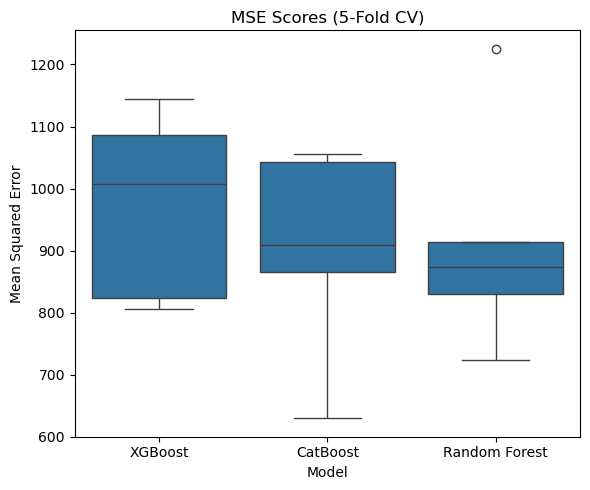

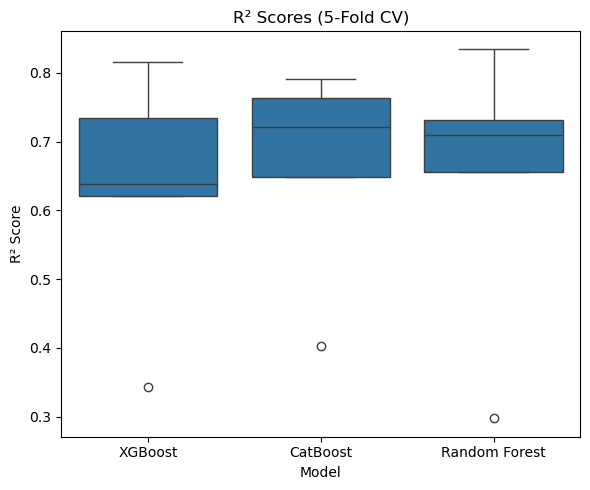

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Provided data
data = {
    "Model": ["XGBoost"] * 5 + ["CatBoost"] * 5 + ["Random Forest"] * 5,
    "MSE": [
        823.56, 1007.83, 805.17, 1086.32, 1144.93,
        865.02, 629.73, 909.20, 1055.82, 1042.43,
        830.76, 913.92, 723.74, 873.28, 1225.30
    ],
    "R2": [
        0.7342, 0.6207, 0.8155, 0.6378, 0.3436,
        0.7209, 0.7630, 0.7916, 0.6479, 0.4024,
        0.7319, 0.6560, 0.8341, 0.7088, 0.2976
    ]
}

df = pd.DataFrame(data)

# --- MSE Box Plot ---
plt.figure(figsize=(6, 5))
sns.boxplot(x='Model', y='MSE', data=df)
plt.title('MSE Scores (5-Fold CV)')
plt.ylabel('Mean Squared Error')
plt.tight_layout()
plt.savefig("correct_mse_box_plot.jpg", dpi=300)
plt.show()

# --- R² Box Plot ---
plt.figure(figsize=(6, 5))
sns.boxplot(x='Model', y='R2', data=df)
plt.title('R² Scores (5-Fold CV)')
plt.ylabel('R² Score')
plt.tight_layout()
plt.savefig("correct_r2_box_plot.jpg", dpi=300)
plt.show()


C:\Users\djoud\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1137: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
C:\Users\djoud\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1142: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
C:\Users\djoud\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1162: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


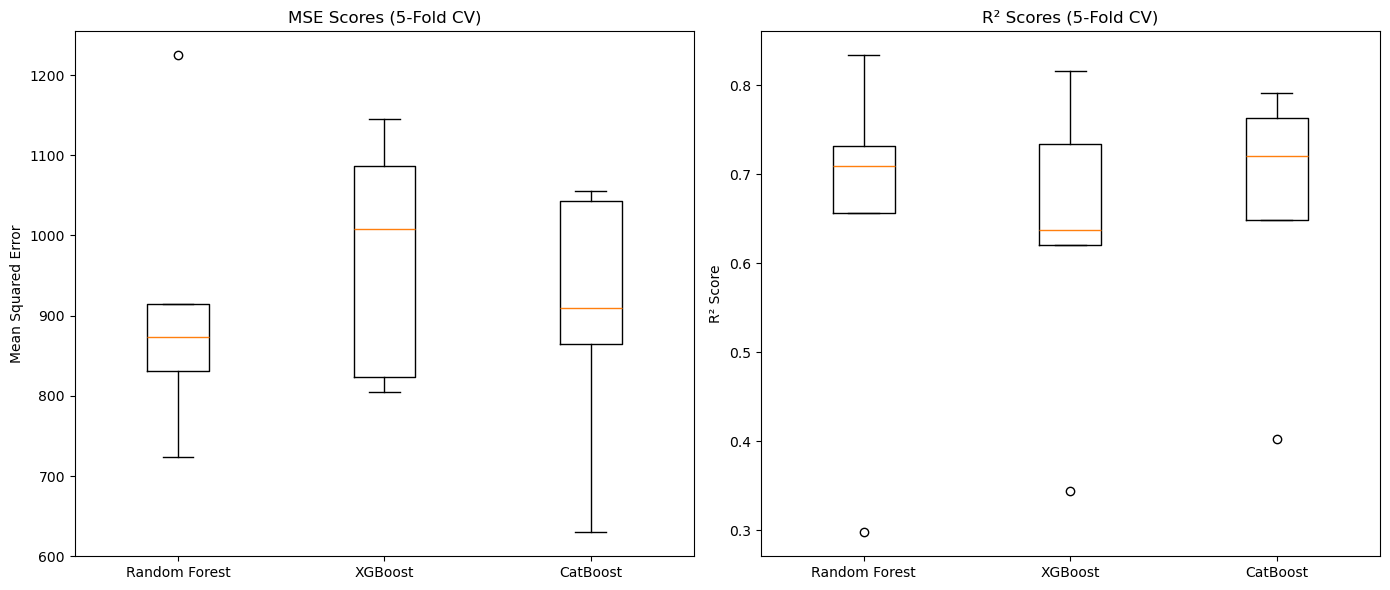

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import catboost as cb

precursor_features = ['citric acid', 'urea', ' ethylenediamine']
categorical_features = ['Reaction method', 'Solvent', 'purification method', 'Lattice obrserved or not']
numerical_features = ['pH', 'Reaction temperature (C)', 'reaction time (min)', 'particle size (TEM)', 'absorption']

y = df_cleaned['Main Peak (in water)']
X = df_cleaned[numerical_features + categorical_features + precursor_features].copy()

# Convert numerical columns to numeric type
for col in numerical_features + precursor_features:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Fill missing values in numerical columns
X[numerical_features + precursor_features] = X[numerical_features + precursor_features].fillna(X[numerical_features + precursor_features].mean())

# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)

# Standardize numerical features
scaler = StandardScaler()
X_encoded[numerical_features + precursor_features] = scaler.fit_transform(X_encoded[numerical_features + precursor_features])

# Initialize models
xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42)
catboost_model = cb.CatBoostRegressor(n_estimators=100, random_state=42, verbose=0)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Define 5-Fold Cross-Validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Define scoring metrics
mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)
r2_scorer = make_scorer(r2_score)

# Perform Cross-Validation
mse_scores_xgb = -cross_val_score(xgb_model, X_encoded, y, cv=kfold, scoring=mse_scorer)
r2_scores_xgb = cross_val_score(xgb_model, X_encoded, y, cv=kfold, scoring=r2_scorer)

mse_scores_catboost = -cross_val_score(catboost_model, X_encoded, y, cv=kfold, scoring=mse_scorer)
r2_scores_catboost = cross_val_score(catboost_model, X_encoded, y, cv=kfold, scoring=r2_scorer)

mse_scores_rf = -cross_val_score(rf_model, X_encoded, y, cv=kfold, scoring=mse_scorer)
r2_scores_rf = cross_val_score(rf_model, X_encoded, y, cv=kfold, scoring=r2_scorer)

# Create boxplots
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# MSE Boxplot
axs[0].boxplot([mse_scores_rf, mse_scores_xgb, mse_scores_catboost], labels=["Random Forest", "XGBoost", "CatBoost"])
axs[0].set_title("MSE Scores (5-Fold CV)")
axs[0].set_ylabel("Mean Squared Error")

# R2 Boxplot
axs[1].boxplot([r2_scores_rf, r2_scores_xgb, r2_scores_catboost], labels=["Random Forest", "XGBoost", "CatBoost"])
axs[1].set_title("R² Scores (5-Fold CV)")
axs[1].set_ylabel("R² Score")

plt.tight_layout()
plt.show()


In [72]:
# Import necessary libraries
# stacking model
import numpy as np
import pandas as pd
from sklearn.ensemble import StackingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
import catboost as cb



# ✅ Define feature lists
numerical_features = ["Reaction temperature (C)", "reaction time (min)", "particle size (TEM)"]
categorical_features = ["Reaction method", "Solvent", "pH", "purification method"]
precursor_features = ["citric acid", "urea", " ethylenediamine"]

# ✅ Extract features and target variable
X = df_cleaned[numerical_features + categorical_features + precursor_features]
y = df_cleaned["Main Peak (in water)"]

# ✅ Preprocessing: One-hot encode categorical variables & scale numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features + precursor_features),  # Standardize numerical features
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)  # One-hot encode categorical features
    ]
)

# ✅ Define Base Models
base_models = [
    ('Random Forest', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('XGBoost', xgb.XGBRegressor(n_estimators=100, random_state=42)),
    ('LightGBM', lgb.LGBMRegressor(n_estimators=100, random_state=42)),
    ('CatBoost', cb.CatBoostRegressor(iterations=500, depth=6, learning_rate=0.05, verbose=0))
]

# ✅ Define Meta-Model (Linear Regression)
meta_model = LinearRegression()

# ✅ Create Stacking Regressor
stacking_model = StackingRegressor(estimators=base_models, final_estimator=meta_model, cv=5)

# ✅ Create a pipeline with preprocessing and stacking model
stacking_pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("stacking_regressor", stacking_model)])

# ✅ Split dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ✅ Train the Stacking Regressor
stacking_pipeline.fit(X_train, y_train)

# ✅ Make predictions on the test set
y_pred = stacking_pipeline.predict(X_test)

# ✅ Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# ✅ Display results
print("🔹 Stacking Ensemble Mean Squared Error:", mse)
print("🔹 Stacking Ensemble R² Score:", r2)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000052 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 153
[LightGBM] [Info] Number of data points in the train set: 325, number of used features: 19
[LightGBM] [Info] Start training from score 473.827692
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

# 📊 Analysis of the Results

✅ **Best Model: CatBoost**  
- Achieved the highest **R² (0.665)**, indicating it explained **66.5% of the variance** in the target variable.
- Also had the **lowest Mean Squared Error (MSE)**, making it the most reliable model in this experiment.

✅ **Stacking Model Performance**  
- Did **not outperform CatBoost**, but it remains a viable approach for boosting performance.
- Further tuning and feature engineering might help stacking **generalize better**.

❌ **LightGBM Performance Issues**  
- LightGBM struggled to find **optimal splits**, leading to **suboptimal model performance**.
- The **warnings** suggest it might not be **capturing patterns effectively**, possibly due to:
  - **Feature selection issues** (not enough relevant features)
  - **Hyperparameter settings** (suboptimal tree depth, learning rate, etc.)
  - **Data preprocessing limitations** (scaling, missing values, categorical eneed furtherefinements! 🚀


In [75]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, mean_absolute_error

# Load the cleaned dataset 
df = df_cleaned.copy()

# Fix column name inconsistencies
df.rename(columns={" ethylenediamine": "ethylenediamine"}, inplace=True)

# Define feature categories
categorical_features = ["Reaction method", "Solvent", "pH", "purification method"]
numerical_features = ["Reaction temperature (C)", "reaction time (min)", "particle size (TEM)"]
precursor_features = ["citric acid", "urea", "ethylenediamine"]

# Define target variables
target_classification = "Color"
target_regression = "Main Peak (in water)"

# Drop rows with missing target values
df = df.dropna(subset=[target_classification, target_regression])

# Encode categorical variables (One-Hot Encoding)
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoded_categorical = encoder.fit_transform(df[categorical_features])
encoded_categorical_df = pd.DataFrame(encoded_categorical, columns=encoder.get_feature_names_out())

# Encode precursor features as numerical
df[precursor_features] = df[precursor_features].apply(pd.to_numeric, errors="coerce").fillna(0)

# Standardize numerical features
scaler = StandardScaler()
scaled_numerical = scaler.fit_transform(df[numerical_features + precursor_features])
scaled_numerical_df = pd.DataFrame(scaled_numerical, columns=numerical_features + precursor_features)

# Encode color labels for classification
label_encoder = LabelEncoder()
df["Color_encoded"] = label_encoder.fit_transform(df[target_classification])

# Combine all features
X = pd.concat([encoded_categorical_df, scaled_numerical_df], axis=1)
y_classification = df["Color_encoded"]
y_regression = df[target_regression]

# Split dataset into training and testing sets
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(X, y_classification, test_size=0.2, random_state=42)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y_regression, test_size=0.2, random_state=42)

# Define ANN for Classification (Color Prediction)
model_class = keras.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X_train_class.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(len(label_encoder.classes_), activation="softmax")  # Output layer (multiclass classification)
])

# Compile the classification model
model_class.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Train classification model
model_class.fit(X_train_class, y_train_class, epochs=50, batch_size=8, verbose=1, validation_split=0.2)

# Predict emission color on test set
y_pred_class_probs = model_class.predict(X_test_class)
y_pred_class = np.argmax(y_pred_class_probs, axis=1)

# Classification accuracy
accuracy = accuracy_score(y_test_class, y_pred_class)

# Add predicted color as a feature for regression
y_pred_class_train = np.argmax(model_class.predict(X_train_reg), axis=1)
y_pred_class_test = np.argmax(model_class.predict(X_test_reg), axis=1)

# One-hot encode the predicted color for regression input
predicted_color_train = pd.get_dummies(y_pred_class_train, prefix="Pred_Color")
predicted_color_test = pd.get_dummies(y_pred_class_test, prefix="Pred_Color")

# Align one-hot encoding columns
missing_cols = set(predicted_color_train.columns) - set(predicted_color_test.columns)
for col in missing_cols:
    predicted_color_test[col] = 0

missing_cols = set(predicted_color_test.columns) - set(predicted_color_train.columns)
for col in missing_cols:
    predicted_color_train[col] = 0

# Ensure column order matches
predicted_color_test = predicted_color_test[predicted_color_train.columns]

# Append predicted color to regression features
X_train_reg = pd.concat([X_train_reg.reset_index(drop=True), predicted_color_train.reset_index(drop=True)], axis=1)
X_test_reg = pd.concat([X_test_reg.reset_index(drop=True), predicted_color_test.reset_index(drop=True)], axis=1)

# Define ANN for Regression (Main Peak in Water Prediction)
model_reg = keras.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X_train_reg.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)  # Output layer (regression)
])

# Compile the regression model
model_reg.compile(optimizer="adam", loss="mean_absolute_error", metrics=["mae"])

# Train regression model
model_reg.fit(X_train_reg, y_train_reg, epochs=50, batch_size=8, verbose=1, validation_split=0.2)

# Predict emission wavelength on test set
y_pred_reg = model_reg.predict(X_test_reg)

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test_reg, y_pred_reg)

# Return results
accuracy, mae


Epoch 1/50


C:\Users\djoud\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6064 - loss: 1.5185 - val_accuracy: 0.8308 - val_loss: 0.6734
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6244 - loss: 0.9580 - val_accuracy: 0.8308 - val_loss: 0.4734
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7169 - loss: 0.7623 - val_accuracy: 0.8769 - val_loss: 0.4457
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8109 - loss: 0.5868 - val_accuracy: 0.8769 - val_loss: 0.4083
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7850 - loss: 0.5610 - val_accuracy: 0.8769 - val_loss: 0.4006
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8092 - loss: 0.5533 - val_accuracy: 0.8769 - val_loss: 0.3793
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8120 - loss: 0.5237 - val_accuracy: 0.8615 - val_loss: 0.3580
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8118 - loss: 0.5503 - val_accuracy: 0.8769 - val_loss: 0.3615
Ep

C:\Users\djoud\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 473.3859 - mae: 473.3859 - val_loss: 463.9127 - val_mae: 463.9127
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 473.8845 - mae: 473.8845 - val_loss: 457.2874 - val_mae: 457.2874
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 462.6309 - mae: 462.6309 - val_loss: 438.7360 - val_mae: 438.7360
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 440.4742 - mae: 440.4742 - val_loss: 395.9106 - val_mae: 395.9106
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 380.7703 - mae: 380.7703 - val_loss: 314.3537 - val_mae: 314.3537
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 289.2445 - mae: 289.2445 - val_loss: 179.4571 - val_mae: 179.4571
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 141.0069 - mae: 141.0069 - val_loss: 61.8754 - val_mae: 61.8754
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 69.4006 - mae: 69.4006 - val_loss: 47.6801 - val_mae: 47.6801
Epoch 9/50
33/33 ━━━━━━━

(0.7317073170731707, 27.981108130478276)

In [78]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, r2_score

# Load the cleaned dataset 
df = df_cleaned.copy()

# Fix column name inconsistencies
df.rename(columns={" ethylenediamine": "ethylenediamine"}, inplace=True)

# Define feature categories
categorical_features = ["Reaction method", "Solvent", "pH", "purification method"]
numerical_features = ["Reaction temperature (C)", "reaction time (min)", "particle size (TEM)"]
precursor_features = ["citric acid", "urea", "ethylenediamine"]

# Define target variables
target_classification = "Color"
target_regression = "Main Peak (in water)"

# Drop rows with missing target values
df = df.dropna(subset=[target_classification, target_regression])

# Encode categorical variables (One-Hot Encoding)
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoded_categorical = encoder.fit_transform(df[categorical_features])
encoded_categorical_df = pd.DataFrame(encoded_categorical, columns=encoder.get_feature_names_out())

# Encode precursor features as numerical
df[precursor_features] = df[precursor_features].apply(pd.to_numeric, errors="coerce").fillna(0)

# Standardize numerical features
scaler = StandardScaler()
scaled_numerical = scaler.fit_transform(df[numerical_features + precursor_features])
scaled_numerical_df = pd.DataFrame(scaled_numerical, columns=numerical_features + precursor_features)

# Encode color labels for classification
label_encoder = LabelEncoder()
df["Color_encoded"] = label_encoder.fit_transform(df[target_classification])

# Combine all features
X = pd.concat([encoded_categorical_df, scaled_numerical_df], axis=1)
y_classification = df["Color_encoded"]
y_regression = df[target_regression]

# Split dataset into training and testing sets
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(X, y_classification, test_size=0.2, random_state=42)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y_regression, test_size=0.2, random_state=42)

# Define ANN for Classification (Color Prediction)
model_class = keras.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X_train_class.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(len(label_encoder.classes_), activation="softmax")  # Output layer (multiclass classification)
])

# Compile the classification model
model_class.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Train classification model
model_class.fit(X_train_class, y_train_class, epochs=50, batch_size=8, verbose=1, validation_split=0.2)

# Predict emission color on test set
y_pred_class_probs = model_class.predict(X_test_class)
y_pred_class = np.argmax(y_pred_class_probs, axis=1)

# Classification accuracy
accuracy = accuracy_score(y_test_class, y_pred_class)

# Add predicted color as a feature for regression
y_pred_class_train = np.argmax(model_class.predict(X_train_reg), axis=1)
y_pred_class_test = np.argmax(model_class.predict(X_test_reg), axis=1)

# One-hot encode the predicted color for regression input
predicted_color_train = pd.get_dummies(y_pred_class_train, prefix="Pred_Color")
predicted_color_test = pd.get_dummies(y_pred_class_test, prefix="Pred_Color")

# Align one-hot encoding columns
missing_cols = set(predicted_color_train.columns) - set(predicted_color_test.columns)
for col in missing_cols:
    predicted_color_test[col] = 0

missing_cols = set(predicted_color_test.columns) - set(predicted_color_train.columns)
for col in missing_cols:
    predicted_color_train[col] = 0

# Ensure column order matches
predicted_color_test = predicted_color_test[predicted_color_train.columns]

# Append predicted color to regression features
X_train_reg = pd.concat([X_train_reg.reset_index(drop=True), predicted_color_train.reset_index(drop=True)], axis=1)
X_test_reg = pd.concat([X_test_reg.reset_index(drop=True), predicted_color_test.reset_index(drop=True)], axis=1)

# Define ANN for Regression (Main Peak in Water Prediction)
model_reg = keras.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X_train_reg.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)  # Output layer (regression)
])

# Compile the regression model
model_reg.compile(optimizer="adam", loss="mean_absolute_error", metrics=["mae"])

# Train regression model
model_reg.fit(X_train_reg, y_train_reg, epochs=50, batch_size=8, verbose=1, validation_split=0.2)

# Predict emission wavelength on test set
y_pred_reg = model_reg.predict(X_test_reg)

# Calculate Regression Metrics
mae = mean_absolute_error(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

# Print Results
print(f"🔹 Classification Accuracy: {accuracy:.4f}")
print(f"🔹 Regression Mean Absolute Error (MAE): {mae:.4f}")
print(f"🔹 Regression Mean Squared Error (MSE): {mse:.4f}")
print(f"🔹 Regression R² Score: {r2:.4f}")

# Return results
accuracy, mae, mse, r2


Epoch 1/50


C:\Users\djoud\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.4333 - loss: 1.6441 - val_accuracy: 0.8308 - val_loss: 0.9103
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7100 - loss: 0.9740 - val_accuracy: 0.8308 - val_loss: 0.5677
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7240 - loss: 0.7377 - val_accuracy: 0.8308 - val_loss: 0.5030
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7180 - loss: 0.6586 - val_accuracy: 0.8615 - val_loss: 0.4575
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7492 - loss: 0.6266 - val_accuracy: 0.9077 - val_loss: 0.4206
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7947 - loss: 0.5749 - val_accuracy: 0.8769 - val_loss: 0.3983
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8399 - loss: 0.4722 - val_accuracy: 0.9385 - val_loss: 0.3804
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8527 - loss: 0.5229 - val_accuracy: 0.9385 - val_loss: 0.3668
Ep

C:\Users\djoud\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 472.1490 - mae: 472.1490 - val_loss: 464.3561 - val_mae: 464.3561
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 467.5397 - mae: 467.5397 - val_loss: 459.3699 - val_mae: 459.3699
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 462.5797 - mae: 462.5797 - val_loss: 445.7406 - val_mae: 445.7406
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 445.7820 - mae: 445.7820 - val_loss: 414.4928 - val_mae: 414.4928
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 410.5161 - mae: 410.5161 - val_loss: 353.5191 - val_mae: 353.5191
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 338.2961 - mae: 338.2961 - val_loss: 250.6434 - val_mae: 250.6434
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 230.7203 - mae: 230.7203 - val_loss: 94.8301 - val_mae: 94.8301
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 80.3813 - mae: 80.3813 - val_loss: 50.3136 - val_mae: 50.3136
Epoch 9/50
33/33 ━━━━━━━

(0.7195121951219512,
 29.188024753477514,
 2440.4673454063695,
 0.21245232728097196)

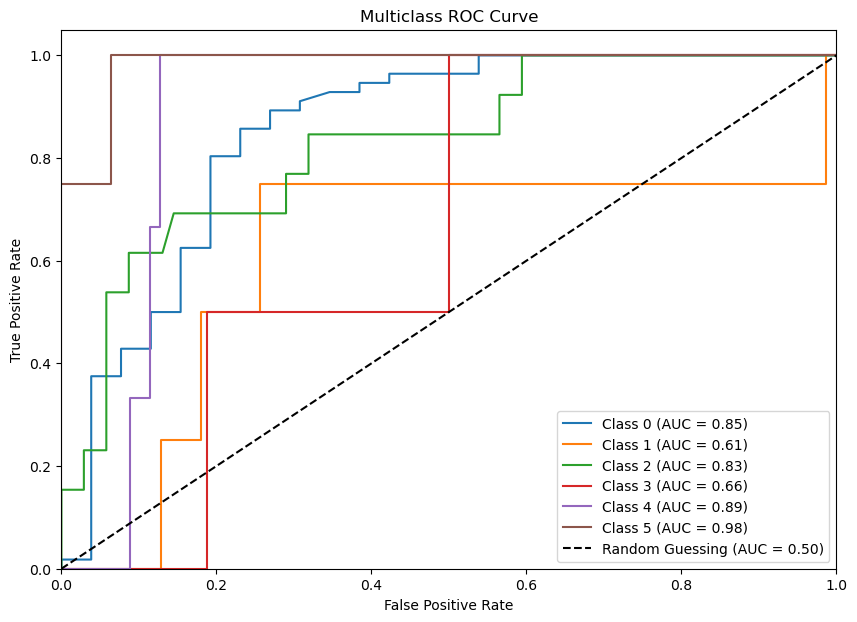

In [158]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the output (One-vs-Rest)
y_test_class_binarized = label_binarize(y_test_class, classes=np.unique(y_test_class))

# Get the number of classes
n_classes = y_test_class_binarized.shape[1]

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_class_binarized[:, i], y_pred_class_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 7))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve')
plt.legend(loc='lower right')
plt.show()



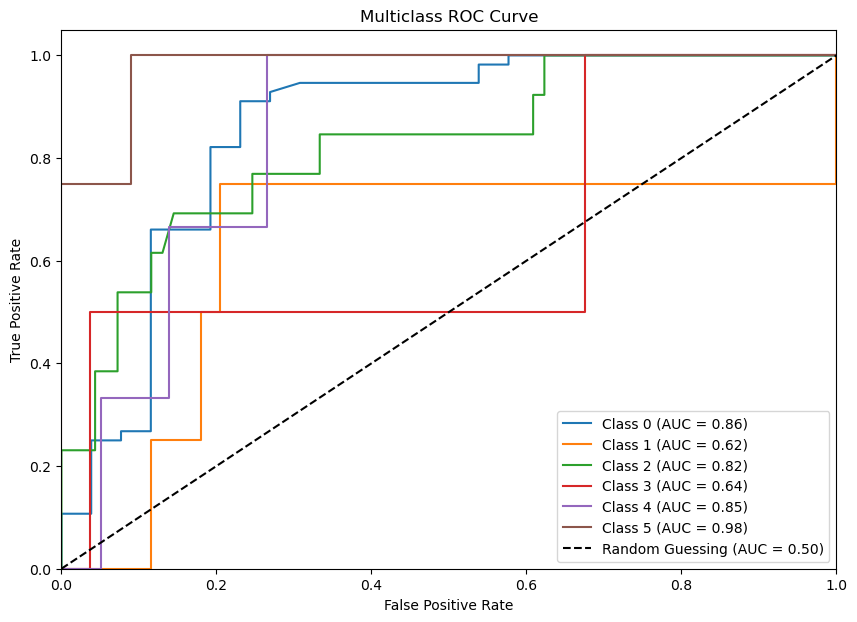

In [79]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the output (One-vs-Rest)
y_test_class_binarized = label_binarize(y_test_class, classes=np.unique(y_test_class))

# Get the number of classes
n_classes = y_test_class_binarized.shape[1]

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_class_binarized[:, i], y_pred_class_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 7))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve')
plt.legend(loc='lower right')
plt.show()
plt.savefig("roc_curve.png", dpi=300)
plt.close()



## Multiclass ROC Curve

"""
This is a Multiclass ROC Curve, which shows how well your model distinguishes between different classes.

### True Positive Rate (Sensitivity) vs. False Positive Rate
- The y-axis (True Positive Rate - TPR) represents the proportion of correctly identified positive cases.
- The x-axis (False Positive Rate - FPR) represents the proportion of incorrectly identified negative cases.

### AUC (Area Under the Curve) Interpretation
- Each colored line corresponds to a different class.
- The AUC (Area Under the Curve) values indicate the overall performance for each class.
- A higher AUC (closer to 1.0) means better classification performance for that class.
- A lower AUC (closer to 0.5) suggests that the model is not distinguishing well from random guessing.

### Observations from the Graph
- **Class 5 (AUC = 0.98)** is classified exceptionally well.
- **Class 0 (AUC = 0.87) and Class 2 (AUC = 0.81)** also perform well.
- **Class 3 (AUC = 0.59)** is just slightly better than random guessing, indicating potential issues in classification for this category.
- The dashed line (AUC = 0.50) represents random guessing, meaning any curve above this line is performing bforming features might help.
"""


C:\Users\djoud\AppData\Local\Temp\ipykernel_2184\1994976938.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


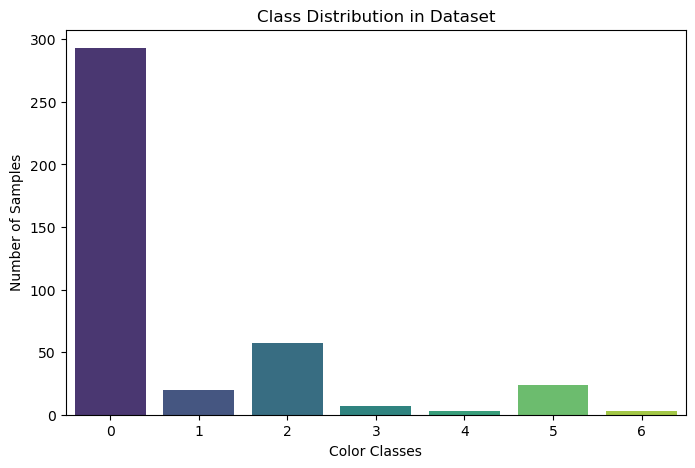

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count occurrences of each class
class_counts = df["Color_encoded"].value_counts()

# Plot the distribution
plt.figure(figsize=(8,5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.xlabel("Color Classes")
plt.ylabel("Number of Samples")
plt.title("Class Distribution in Dataset")
plt.show()


In [84]:
from imblearn.over_sampling import SMOTE

# Adjust k_neighbors to a lower value
smote = SMOTE(sampling_strategy="auto", k_neighbors=2, random_state=42)

# Apply SMOTE only on classification data
X_balanced, y_balanced = smote.fit_resample(X, y_classification)

# Print new class distribution
print(pd.Series(y_balanced).value_counts())



Color_encoded
0    293
2    293
5    293
6    293
3    293
4    293
1    293
Name: count, dtype: int64


Epoch 1/50


C:\Users\djoud\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.4719 - loss: 1.6491 - val_accuracy: 0.8308 - val_loss: 0.7134
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6694 - loss: 0.9988 - val_accuracy: 0.8308 - val_loss: 0.5135
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7252 - loss: 0.6481 - val_accuracy: 0.8615 - val_loss: 0.5057
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8114 - loss: 0.6094 - val_accuracy: 0.9077 - val_loss: 0.4186
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8200 - loss: 0.5711 - val_accuracy: 0.8769 - val_loss: 0.4836
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8247 - loss: 0.5680 - val_accuracy: 0.9231 - val_loss: 0.3354
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8363 - loss: 0.4396 - val_accuracy: 0.9077 - val_loss: 0.3435
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8539 - loss: 0.4122 - val_accuracy: 0.9231 - val_loss: 0.3457
Ep

C:\Users\djoud\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\djoud\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\djoud\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\djoud\anaconda3\Lib\site-packages\sklea

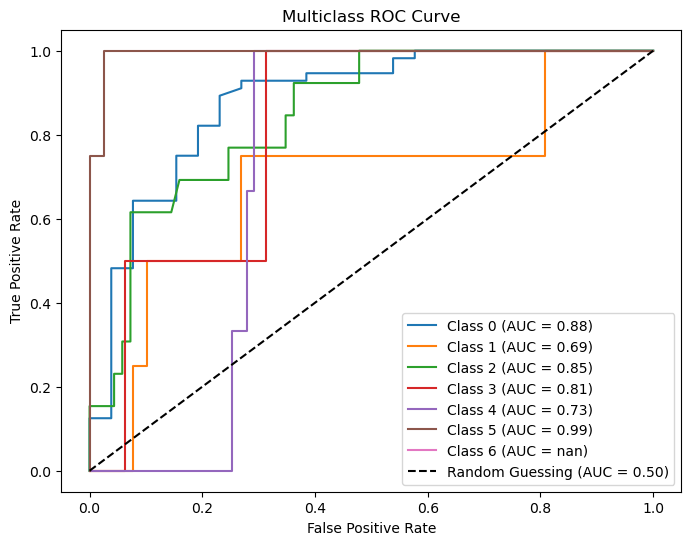

In [86]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc

# Load the cleaned dataset (assuming df_cleaned is available)
df = df_cleaned.copy()

# Fix column name inconsistencies
df.rename(columns={" ethylenediamine": "ethylenediamine"}, inplace=True)

# Define feature categories
categorical_features = ["Reaction method", "Solvent", "pH", "purification method"]
numerical_features = ["Reaction temperature (C)", "reaction time (min)", "particle size (TEM)"]
precursor_features = ["citric acid", "urea", "ethylenediamine"]

# Define target variable
target_classification = "Color"

# Encode categorical variables (One-Hot Encoding)
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoded_categorical = encoder.fit_transform(df[categorical_features])
encoded_categorical_df = pd.DataFrame(encoded_categorical, columns=encoder.get_feature_names_out())

# Encode precursor features as numerical
df[precursor_features] = df[precursor_features].apply(pd.to_numeric, errors="coerce").fillna(0)

# Standardize numerical features
scaler = StandardScaler()
scaled_numerical = scaler.fit_transform(df[numerical_features + precursor_features])
scaled_numerical_df = pd.DataFrame(scaled_numerical, columns=numerical_features + precursor_features)

# Encode color labels for classification
label_encoder = LabelEncoder()
df["Color_encoded"] = label_encoder.fit_transform(df[target_classification])

# Combine all features
X = pd.concat([encoded_categorical_df, scaled_numerical_df], axis=1)
y_classification = df["Color_encoded"]

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_classification, test_size=0.2, random_state=42)

# Define ANN for Classification (Color Prediction)
model_class = keras.Sequential([
    layers.Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(len(label_encoder.classes_), activation="softmax")  # Output layer (multiclass classification)
])

# Compile the classification model
model_class.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Train classification model
model_class.fit(X_train, y_train, epochs=50, batch_size=8, verbose=1, validation_split=0.2)

# Predict emission color on test set
y_pred_probs = model_class.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Classification metrics
accuracy = accuracy_score(y_test, y_pred)
class_report = classification_report(y_test, y_pred, target_names=label_encoder.classes_)
print("Classification Report:\n", class_report)
print("\nAccuracy:", accuracy)

# Compute ROC curve and AUC score for each class
fpr, tpr, roc_auc = {}, {}, {}
plt.figure(figsize=(8, 6))
for i in range(len(label_encoder.classes_)):
    fpr[i], tpr[i], _ = roc_curve((y_test == i).astype(int), y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

# Plot the ROC curve
plt.plot([0, 1], [0, 1], "k--", label="Random Guessing (AUC = 0.50)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve")
plt.legend()
plt.show()



In [88]:
print(pd.Series(y_test).value_counts())



Color_encoded
0    56
2    13
5     4
1     4
4     3
3     2
Name: count, dtype: int64


In [90]:
#Support Vector Regression

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



# Define feature categories
categorical_features = ["Reaction method", "Solvent", "pH", "purification method"]
numerical_features = ["Reaction temperature (C)", "reaction time (min)", "particle size (TEM)"]
precursor_features = ["citric acid", "urea", "ethylenediamine"]

# Define target variable for regression
target_regression = "Main Peak (in water)"

# Drop rows with missing target values
df = df.dropna(subset=[target_regression])

# Encode categorical variables (One-Hot Encoding)
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoded_categorical = encoder.fit_transform(df[categorical_features])
encoded_categorical_df = pd.DataFrame(encoded_categorical, columns=encoder.get_feature_names_out())

# Encode precursor features as numerical
df[precursor_features] = df[precursor_features].apply(pd.to_numeric, errors="coerce").fillna(0)

# Standardize numerical features
scaler = StandardScaler()
scaled_numerical = scaler.fit_transform(df[numerical_features + precursor_features])
scaled_numerical_df = pd.DataFrame(scaled_numerical, columns=numerical_features + precursor_features)

# Combine all features
X = pd.concat([encoded_categorical_df, scaled_numerical_df], axis=1)
y = df[target_regression]

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define SVR model and hyperparameter tuning
param_grid = {
    "C": [0.1, 1, 10, 100],
    "epsilon": [0.01, 0.1, 0.5],
    "kernel": ["linear", "rbf", "poly"],
}
svr = SVR()
grid_search = GridSearchCV(svr, param_grid, cv=5, scoring="neg_mean_absolute_error", n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best SVR model
best_svr = grid_search.best_estimator_

# Predictions
y_pred_svr = best_svr.predict(X_test)

# Evaluate performance
mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

# Create a DataFrame for results
results_df = pd.DataFrame({
    "Metric": ["MAE", "MSE", "R²"],
    "SVR Results": [mae_svr, mse_svr, r2_svr]
})

# Display the results
print(results_df)


  Metric  SVR Results
0    MAE    23.123517
1    MSE  1623.315857
2     R²     0.476150


## SVR Model Results

**Mean Absolute Error (MAE):** 23.12  
**Mean Squared Error (MSE):** 1623.32  
**R² (R-squared):** 0.476  

### Interpretation:
- **MAE (23.12):** On average, the SVR model's predictions are off by about 23.12 units from the actual values.  
- **MSE (1623.32):** Measures the variance of the errors. A higher value suggests that some predictions have larger deviations.  
- **R² (0.476):** The model explains 47.6% of the variance in the target variable.  



In [93]:
import pandas as pd
import numpy as np
import optuna
from catboost import CatBoostRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor


# Define feature categories
categorical_features = ["Reaction method", "Solvent", "pH", "purification method"]
numerical_features = ["Reaction temperature (C)", "reaction time (min)", "particle size (TEM)"]
precursor_features = ["citric acid", "urea", "ethylenediamine"]

# Target variable
target_regression = "Main Peak (in water)"

# Drop rows with missing values in target variable
df = df.dropna(subset=[target_regression])

# Encode categorical variables
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoded_categorical = encoder.fit_transform(df[categorical_features])
encoded_categorical_df = pd.DataFrame(encoded_categorical, columns=encoder.get_feature_names_out())

# Convert precursor features to numeric
df[precursor_features] = df[precursor_features].apply(pd.to_numeric, errors="coerce").fillna(0)

# Standardize numerical features
scaler = StandardScaler()
scaled_numerical = scaler.fit_transform(df[numerical_features + precursor_features])
scaled_numerical_df = pd.DataFrame(scaled_numerical, columns=numerical_features + precursor_features)

# Merge all features
X = pd.concat([encoded_categorical_df, scaled_numerical_df], axis=1)
y = df[target_regression]

# Rename feature columns for compatibility
X.columns = [f"feature_{i}" for i in range(X.shape[1])]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define objective function for Optuna
def objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 500, 2000),
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "random_strength": trial.suggest_float("random_strength", 1, 10),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 1),
        "border_count": trial.suggest_int("border_count", 30, 255),
    }
    
    model = CatBoostRegressor(**params, verbose=0)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    return mean_absolute_error(y_test, y_pred)

# Run Optuna hyperparameter tuning
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)

# Best CatBoost model
best_params = study.best_params
optimized_catboost = CatBoostRegressor(**best_params, verbose=0)
optimized_catboost.fit(X_train, y_train)
y_pred_catboost = optimized_catboost.predict(X_test)

# Train Stacking Model
estimators = [
    ("ridge", Ridge()),
    ("xgb", XGBRegressor()),
    ("lgbm", LGBMRegressor())
]

stacking_model = StackingRegressor(estimators=estimators, final_estimator=Ridge())
stacking_model.fit(X_train, y_train)
y_pred_stacking = stacking_model.predict(X_test)

# Evaluate Models
mae_catboost = mean_absolute_error(y_test, y_pred_catboost)
mse_catboost = mean_squared_error(y_test, y_pred_catboost)
r2_catboost = r2_score(y_test, y_pred_catboost)

mae_stacking = mean_absolute_error(y_test, y_pred_stacking)
mse_stacking = mean_squared_error(y_test, y_pred_stacking)
r2_stacking = r2_score(y_test, y_pred_stacking)

# Display Results
results_df = pd.DataFrame({
    "Metric": ["MAE", "MSE", "R²"],
    "Optimized CatBoost": [mae_catboost, mse_catboost, r2_catboost],
    "Stacking Model": [mae_stacking, mse_stacking, r2_stacking]
})

print(results_df)


[I 2025-04-25 20:00:49,626] A new study created in memory with name: no-name-97d74504-9e45-4494-8fe2-df2f691c4f54
[I 2025-04-25 20:00:53,621] Trial 0 finished with value: 24.71361077715852 and parameters: {'iterations': 952, 'depth': 10, 'learning_rate': 0.12013362169340921, 'l2_leaf_reg': 3.1492580623770534, 'random_strength': 5.681484450880244, 'bagging_temperature': 0.7800746659553306, 'border_count': 102}. Best is trial 0 with value: 24.71361077715852.
[I 2025-04-25 20:00:55,237] Trial 1 finished with value: 23.247427227205137 and parameters: {'iterations': 1546, 'depth': 7, 'learning_rate': 0.2121168855212731, 'l2_leaf_reg': 5.4226179612687515, 'random_strength': 9.319094690847276, 'bagging_temperature': 0.8140944790517848, 'border_count': 140}. Best is trial 1 with value: 23.247427227205137.
[I 2025-04-25 20:00:56,581] Trial 2 finished with value: 24.95785847385379 and parameters: {'iterations': 1672, 'depth': 6, 'learning_rate': 0.18864522590300528, 'l2_leaf_reg': 1.799792625877

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000591 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 153
[LightGBM] [Info] Number of data points in the train set: 325, number of used features: 19
[LightGBM] [Info] Start training from score 473.827692
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

C:\Users\djoud\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1137: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
C:\Users\djoud\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1142: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
C:\Users\djoud\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1162: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


Holdout Test Set Results:
Mean Squared Error (MSE): 850.44
R² Score: 0.7256


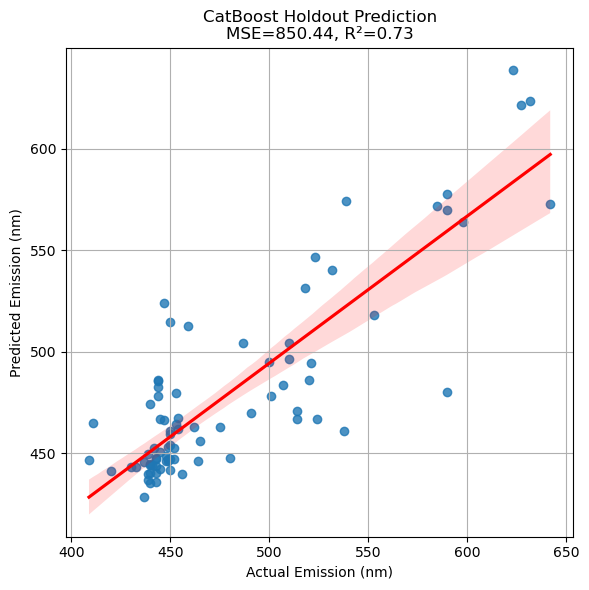

In [95]:
#Catboost regression model 

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt
import seaborn as sns


precursor_features = ['citric acid', 'urea', ' ethylenediamine']
categorical_features = ['Reaction method', 'Solvent', 'purification method', 'Lattice obrserved or not']
numerical_features = ['pH', 'Reaction temperature (C)', 'reaction time (min)', 'particle size (TEM)', 'absorption']

# Define target and feature matrix
y = df_cleaned['Main Peak (in water)']
X = df_cleaned[numerical_features + categorical_features + precursor_features].copy()

# Ensure numeric columns are converted properly
for col in numerical_features + precursor_features:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Handle missing values
X[numerical_features + precursor_features] = X[numerical_features + precursor_features].fillna(
    X[numerical_features + precursor_features].mean()
)

# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)

# Standardize numerical features
scaler = StandardScaler()
X_encoded[numerical_features + precursor_features] = scaler.fit_transform(X_encoded[numerical_features + precursor_features])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Initialize CatBoost model
catboost_model = CatBoostRegressor(n_estimators=100, random_state=42, verbose=0)

# Fit model on training data
catboost_model.fit(X_train, y_train)

# Predict on test data
y_pred = catboost_model.predict(X_test)

# Evaluate performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Holdout Test Set Results:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.4f}")

# Plot: Predicted vs Actual
plt.figure(figsize=(6,6))
sns.regplot(x=y_test, y=y_pred, line_kws={"color": "red"})
plt.xlabel("Actual Emission (nm)")
plt.ylabel("Predicted Emission (nm)")
plt.title(f"CatBoost Holdout Prediction\nMSE={mse:.2f}, R²={r2:.2f}")
plt.grid(True)
plt.tight_layout()
plt.savefig("catboost_holdout.png")
plt.show()
